In [1]:
from classy_NEDE import Class
from classy import Class as Class_LCDM
import numpy as np

In [2]:
lcdm_params = {
    'output': 'tCl,pCl,lCl,mPk',
    'omega_cdm': 0.12,
    'omega_b': 0.022,
    'h': 0.67,
    'ln10^{10}A_s': 3.05,
    'n_s': 0.965,
    'tau_reio': 0.06,
    'lensing': 'yes'
}

NEDE_lcdm_params = {
    'output': 'tCl,pCl,lCl,mPk',
    'omega_cdm': 0.12,
    'omega_b': 0.022,
    'h': 0.67,
    'ln10^{10}A_s': 3.05,
    'n_s': 0.965,
    'tau_reio': 0.06,
    'lensing': 'yes',
    'delta_Neff_drmd': 0,
    'log10z_stop': 2,
    'f_idm_drmd': 0.0,
    'G_over_aH_drmd_ini': 0
}

class_lcdm = Class_LCDM()
class_lcdm.set(lcdm_params)
class_lcdm.compute()

class_nede_lcdm = Class()
class_nede_lcdm.set(NEDE_lcdm_params)
class_nede_lcdm.compute()



/tmp/ipykernel_1667046/2079541751.py:11: RuntimeWarning: invalid value encountered in divide
  percent_difference = 100 * (clls_nede - clls) / clls


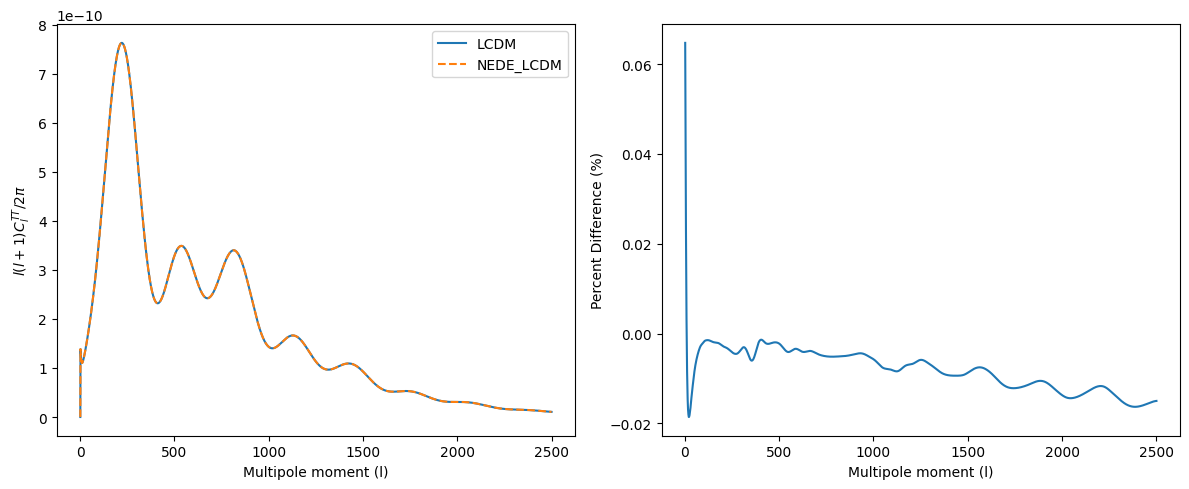

In [3]:
import matplotlib.pyplot as plt

cls_lcdm = class_lcdm.lensed_cl(2500)
clls = cls_lcdm['tt'][1:]
ells = cls_lcdm['ell'][1:]

cls_nede_lcdm = class_nede_lcdm.lensed_cl(2500)
clls_nede = cls_nede_lcdm['tt'][1:]
ells_nede = cls_nede_lcdm['ell'][1:]

percent_difference = 100 * (clls_nede - clls) / clls

fig,ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(ells, clls * ells * (ells + 1) / (2 * 3.14159), label='LCDM')
ax[0].plot(ells_nede, clls_nede * ells_nede * (ells_nede + 1) / (2 * 3.14159), label='NEDE_LCDM', linestyle='--')
ax[0].set_xlabel('Multipole moment (l)')
ax[1].plot(ells, percent_difference, label='Percent Difference')
ax[1].set_xlabel('Multipole moment (l)')
ax[1].set_ylabel('Percent Difference (%)')
#ax[1].set_ylim(-0.05, 0.05)
ax[0].set_ylabel(r'$l(l+1)C_l^{TT}/2\pi$')
ax[0].legend()
plt.tight_layout()
plt.show()

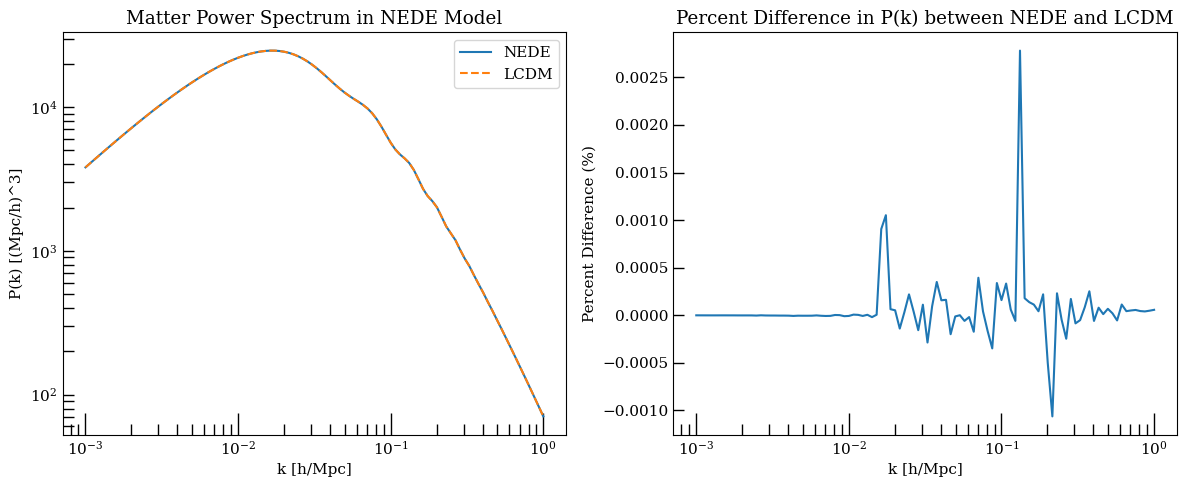

In [10]:
class_NEDE = Class()

NEDE_params = {
    'output': 'tCl,pCl,lCl,mPk',
    'omega_cdm': 0.12,
    'omega_b': 0.022,
    'h': 0.67,
    'ln10^{10}A_s': 3.05,
    'n_s': 0.965,
    'tau_reio': 0.06,
    'lensing': 'yes',
    'delta_Neff_drmd': 0.0,
    'log10z_stop': 2,
    'f_idm_drmd': 0.0,
    'G_over_aH_drmd_ini': 0.0
}
class_NEDE.set(NEDE_params)
class_NEDE.compute()

h = 0.67
k_values = np.logspace(-3, 0, 100)
k_class = k_values * h
P_k_NEDE = np.array([class_NEDE.pk(k, 0.0) for k in k_class])
P_k_LCDM = np.array([class_lcdm.pk(k, 0.0) for k in k_class])

P_k_NEDE = P_k_NEDE * h**3
P_k_LCDM = P_k_LCDM * h**3

percent_differrence_pk = 100 * (P_k_NEDE - P_k_LCDM) / P_k_LCDM

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(k_values, P_k_NEDE, label='NEDE')
ax[0].plot(k_values, P_k_LCDM, linestyle='--', label='LCDM')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('k [h/Mpc]')
ax[0].set_ylabel('P(k) [(Mpc/h)^3]')
ax[0].set_title('Matter Power Spectrum in NEDE Model')
ax[0].legend(['NEDE', 'LCDM'])

# Make axis lines appear inside and bigger
# Make axis lines appear inside and bigger
ax[0].tick_params(axis='both', which='both', direction='in', length=8, width=1)
ax[0].tick_params(axis='x', which='major', length=16, width=1)  # Longer ticks for major x-ticks (1,10,100,...)


ax[1].plot(k_values, percent_differrence_pk)
ax[1].set_xscale('log')
ax[1].set_xlabel('k [h/Mpc]')
ax[1].set_ylabel('Percent Difference (%)')
ax[1].set_title('Percent Difference in P(k) between NEDE and LCDM')
# Make axis lines appear inside and bigger
ax[1].tick_params(axis='both', which='both', direction='in', length=8, width=1)
ax[1].tick_params(axis='x', which='major', length=16, width=1)  # Longer ticks for major x-ticks (1,10,100,...)
plt.tight_layout()


plt.show()

In [20]:
k_values = np.logspace(-3, 0, 10000)
h = 0.67

def f_idm_model(f_idm_drmd_value, delta_Neff, log10z_stop, G_over_aH_drmd):
    class_NEDE = Class()
    class_lcdm = Class()
    value = f_idm_drmd_value

    params_NEDE = {
        'output': 'mPk, tCl, pCl',
        'omega_cdm': 0.12,
        'omega_b': 0.022,
        'h': h,
        'ln10^{10}A_s': 3.05,
        'n_s': 0.965,
        'tau_reio': 0.06,
        'delta_Neff_drmd': delta_Neff,
        'log10z_stop': log10z_stop,
        'log10_G_over_aH_drmd': G_over_aH_drmd,
        'f_idm_drmd': value
    }

    params_lcdm = {
        'output': 'mPk, tCl, pCl',
        'omega_cdm': 0.12,
        'omega_b': 0.022,
        'h': h,
        'ln10^{10}A_s': 3.05,
        'n_s': 0.965,
        'tau_reio': 0.06,
        'delta_Neff_drmd': 0,
        'log10z_stop': 2,
        'log10_G_over_aH_drmd': 0,
        'f_idm_drmd': 0.0
    }

    class_NEDE.set(params_NEDE); class_NEDE.compute()
    class_lcdm.set(params_lcdm); class_lcdm.compute()

    k_range = k_values * h

    # Power spectra
    p_k_NEDE = np.array([class_NEDE.pk(k, 0.0) for k in k_range]) * h**3
    p_k_lcdm = np.array([class_lcdm.pk(k, 0.0) for k in k_range]) * h**3

    # CMB Cls (unlensed)
    cls_NEDE = class_NEDE.raw_cl(2500)
    cls_lcdm = class_lcdm.raw_cl(2500)
    ells = cls_NEDE['ell']
    cls_NEDE_tt = cls_NEDE['tt']
    cls_lcdm_tt = cls_lcdm['tt']

    class_NEDE.struct_cleanup(); class_NEDE.empty()
    class_lcdm.struct_cleanup(); class_lcdm.empty()

    return k_values, p_k_NEDE, p_k_lcdm, ells, cls_NEDE_tt, cls_lcdm_tt



def delta_Neff_model(delta_Neff_value, f_idm_drmd, log10z_stop, G_over_aH_drmd):
    class_NEDE = Class()
    class_lcdm = Class()
    value = delta_Neff_value

    params_NEDE = {
        'output': 'mPk, tCl, pCl',
        'omega_cdm': 0.12,
        'omega_b': 0.022,
        'h': h,
        'ln10^{10}A_s': 3.05,
        'n_s': 0.965,
        'tau_reio': 0.06,
        'delta_Neff_drmd': value,
        'log10z_stop': log10z_stop,
        'log10_G_over_aH_drmd': G_over_aH_drmd,
        'f_idm_drmd': f_idm_drmd
    }

    params_lcdm = {
        'output': 'mPk, tCl, pCl',
        'omega_cdm': 0.12,
        'omega_b': 0.022,
        'h': h,
        'ln10^{10}A_s': 3.05,
        'n_s': 0.965,
        'tau_reio': 0.06,
        'delta_Neff_drmd': 0,
        'log10z_stop': 2,
        'log10_G_over_aH_drmd': 0,
        'f_idm_drmd': 0.0
    }

    class_NEDE.set(params_NEDE); class_NEDE.compute()
    class_lcdm.set(params_lcdm); class_lcdm.compute()

    k_range = k_values * h

    p_k_NEDE = np.array([class_NEDE.pk(k, 0.0) for k in k_range]) * h**3
    p_k_lcdm = np.array([class_lcdm.pk(k, 0.0) for k in k_range]) * h**3

    cls_NEDE = class_NEDE.raw_cl(2500)
    cls_lcdm = class_lcdm.raw_cl(2500)
    ells = cls_NEDE['ell']
    cls_NEDE_tt = cls_NEDE['tt']
    cls_lcdm_tt = cls_lcdm['tt']

    class_NEDE.struct_cleanup(); class_NEDE.empty()
    class_lcdm.struct_cleanup(); class_lcdm.empty()

    return k_values, p_k_NEDE, p_k_lcdm, ells, cls_NEDE_tt, cls_lcdm_tt



def log10z_stop_model(log10z_stop_value, f_idm_drmd, delta_Neff, G_over_aH_drmd):
    class_NEDE = Class()
    class_lcdm = Class()
    value = log10z_stop_value

    params_NEDE = {
        'output': 'mPk, tCl, pCl',
        'omega_cdm': 0.12,
        'omega_b': 0.022,
        'h': h,
        'ln10^{10}A_s': 3.05,
        'n_s': 0.965,
        'tau_reio': 0.06,
        'delta_Neff_drmd': delta_Neff,
        'log10z_stop': value,
        'log10_G_over_aH_drmd': G_over_aH_drmd,
        'f_idm_drmd': f_idm_drmd
    }

    params_lcdm = {
        'output': 'mPk, tCl, pCl',
        'omega_cdm': 0.12,
        'omega_b': 0.022,
        'h': h,
        'ln10^{10}A_s': 3.05,
        'n_s': 0.965,
        'tau_reio': 0.06,
        'delta_Neff_drmd': 0,
        'log10z_stop': 2,
        'log10_G_over_aH_drmd': 0,
        'f_idm_drmd': 0.0
    }

    class_NEDE.set(params_NEDE); class_NEDE.compute()
    class_lcdm.set(params_lcdm); class_lcdm.compute()

    k_range = k_values * h

    p_k_NEDE = np.array([class_NEDE.pk(k, 0.0) for k in k_range]) * h**3
    p_k_lcdm = np.array([class_lcdm.pk(k, 0.0) for k in k_range]) * h**3

    cls_NEDE = class_NEDE.raw_cl(2500)
    cls_lcdm = class_lcdm.raw_cl(2500)
    ells = cls_NEDE['ell']
    cls_NEDE_tt = cls_NEDE['tt']
    cls_lcdm_tt = cls_lcdm['tt']

    class_NEDE.struct_cleanup(); class_NEDE.empty()
    class_lcdm.struct_cleanup(); class_lcdm.empty()

    return k_values, p_k_NEDE, p_k_lcdm, ells, cls_NEDE_tt, cls_lcdm_tt



def G_over_aH_drmd_model(G_over_aH_drmd_value, f_idm_drmd, delta_Neff, log10z_stop):
    class_NEDE = Class()
    class_lcdm = Class()
    value = G_over_aH_drmd_value

    params_NEDE = {
        'output': 'mPk, tCl, pCl',
        'omega_cdm': 0.12,
        'omega_b': 0.022,
        'h': h,
        'ln10^{10}A_s': 3.05,
        'n_s': 0.965,
        'tau_reio': 0.06,
        'delta_Neff_drmd': delta_Neff,
        'log10z_stop': log10z_stop,
        'log10_G_over_aH_drmd': value,
        'f_idm_drmd': f_idm_drmd
    }

    params_lcdm = {
        'output': 'mPk, tCl, pCl',
        'omega_cdm': 0.12,
        'omega_b': 0.022,
        'h': h,
        'ln10^{10}A_s': 3.05,
        'n_s': 0.965,
        'tau_reio': 0.06,
        'delta_Neff_drmd': 0,
        'log10z_stop': 2,
        'log10_G_over_aH_drmd': 0,
        'f_idm_drmd': 0.0
    }

    class_NEDE.set(params_NEDE); class_NEDE.compute()
    class_lcdm.set(params_lcdm); class_lcdm.compute()

    k_range = k_values * h

    p_k_NEDE = np.array([class_NEDE.pk(k, 0.0) for k in k_range]) * h**3
    p_k_lcdm = np.array([class_lcdm.pk(k, 0.0) for k in k_range]) * h**3

    cls_NEDE = class_NEDE.raw_cl(2500)
    cls_lcdm = class_lcdm.raw_cl(2500)
    ells = cls_NEDE['ell']
    cls_NEDE_tt = cls_NEDE['tt']
    cls_lcdm_tt = cls_lcdm['tt']

    class_NEDE.struct_cleanup(); class_NEDE.empty()
    class_lcdm.struct_cleanup(); class_lcdm.empty()

    return k_values, p_k_NEDE, p_k_lcdm, ells, cls_NEDE_tt, cls_lcdm_tt


TypeError: f_idm_model() missing 3 required positional arguments: 'delta_Neff', 'log10z_stop', and 'G_over_aH_drmd'

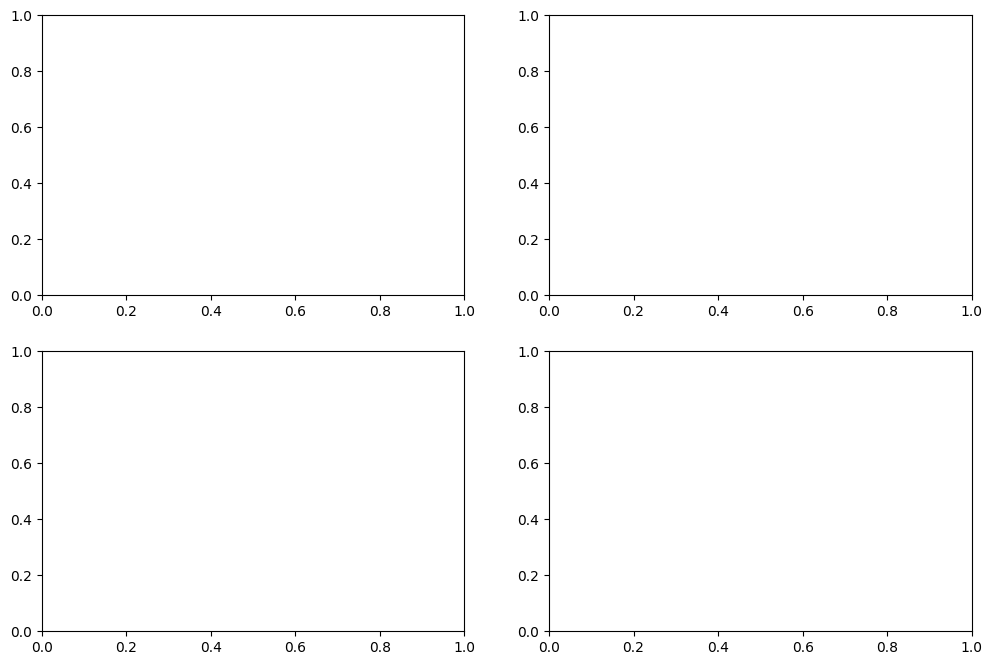

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
interaction_fraction = np.linspace(0, 1, 5)
delta_Neff_values = [0.0, 0.3, 0.6, 0.9, 1.2]
log10z_stop_values = np.linspace(2,5,5)
G_over_aH_drmd_values = np.logspace(2,14,5)

for f_idm in interaction_fraction:
    k_vals, p_k_nede, p_k_lcdm, ells, cls_NEDE, cls_lcdm_tt = f_idm_model(f_idm)
    ax[0, 0].plot(k_vals, p_k_nede, label=f'f_idm_drmd={f_idm:.2f}', linestyle='-')

lcdm_values = f_idm_model(0.0)
ax[0, 0].plot(lcdm_values[0], lcdm_values[2], label='LCDM', linestyle='--')
ax[0, 0].set_xscale('log')
ax[0, 0].set_yscale('log')
ax[0, 0].set_xlabel('k [h/Mpc]')
ax[0, 0].set_ylabel('P(k) [(Mpc/h)^3]')
ax[0, 0].set_title('Matter Power Spectrum for different $f_{idm,drmd}$')
ax[0, 0].tick_params(axis='both', which='both', direction='in', length=8, width=1)
ax[0, 0].tick_params(axis='x', which='major', length=16, width=1)
ax[0, 0].legend()
box_props = dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
ax[0, 0].text(
    ax[0, 0].get_xlim()[0],  
    ax[0, 0].get_ylim()[1],  
    r'$\Delta N_{eff,drmd}=1.0$',  
    bbox=box_props,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='left'
)

for values in delta_Neff_values:
    k_vals, p_k_nede, p_k_lcdm, ells, cls_NEDE_tt, cls_lcdm_tt = delta_Neff_model(values)
    ax[0, 1].plot(k_vals, p_k_nede, label=f'ΔN_eff={values:.2f}', linestyle='-')

lcdm_values = delta_Neff_model(0.0)
ax[0, 1].plot(lcdm_values[0], lcdm_values[2], label='LCDM', linestyle='--')
ax[0, 1].set_xscale('log')
ax[0, 1].set_yscale('log')
ax[0, 1].set_xlabel('k [h/Mpc]')
ax[0, 1].set_ylabel('P(k) [(Mpc/h)^3]')
ax[0, 1].set_title('Matter Power Spectrum for different $\Delta N_{eff}$')
ax[0, 1].tick_params(axis='both', which='both', direction='in', length=8, width=1)
ax[0, 1].tick_params(axis='x', which='major', length=16, width=1)
ax[0, 1].legend()

box_props = dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
ax[0, 1].text(
    ax[0, 1].get_xlim()[0],  
    ax[0, 1].get_ylim()[1],  
    r'$f_{idm,drmd}=0.1$',  
    bbox=box_props,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='left'
)


for log10z_stop in log10z_stop_values:
    k_vals, p_k_nede, p_k_lcdm, ells, cls_NEDE_tt, cls_lcdm_tt = log10z_stop_model(log10z_stop)
    ax[1, 0].plot(k_vals, p_k_nede, label=f'log10z_stop={log10z_stop:.2f}', linestyle='-')

lcdm_values = log10z_stop_model(2.0)
ax[1, 0].plot(lcdm_values[0], lcdm_values[2], label='LCDM', linestyle='--')
ax[1, 0].set_xscale('log')
ax[1, 0].set_yscale('log')
ax[1, 0].set_xlabel('k [h/Mpc]')
ax[1, 0].set_ylabel('P(k) [(Mpc/h)^3]')
ax[1, 0].set_title('Matter Power Spectrum for different $log10z_{stop}$')
ax[1, 0].tick_params(axis='both', which='both', direction='in', length=8, width=1)
ax[1, 0].tick_params(axis='x', which='major', length=16, width=1)
ax[1, 0].legend()


for G_over_aH in G_over_aH_drmd_values:
    k_vals, p_k_nede, p_k_lcdm, ells, cls_NEDE_tt, cls_lcdm_tt = G_over_aH_drmd_model(G_over_aH)
    ax[1, 1].plot(k_vals, p_k_nede, label=f'G/aH={G_over_aH:.2e}', linestyle='-')

lcdm_values = G_over_aH_drmd_model(0.0)
ax[1, 1].plot(lcdm_values[0], lcdm_values[2], label='LCDM', linestyle='--')
ax[1, 1].set_xscale('log')
ax[1, 1].set_yscale('log')
ax[1, 1].set_xlabel('k [h/Mpc]')
ax[1, 1].set_ylabel('P(k) [(Mpc/h)^3]')
ax[1, 1].set_title('Matter Power Spectrum for different $G/(aH)_{drmd}$')
ax[1, 1].tick_params(axis='both', which='both', direction='in', length=8, width=1)
ax[1, 1].tick_params(axis='x', which='major', length=16, width=1)
ax[1, 1].legend()



plt.tight_layout()
plt.show()


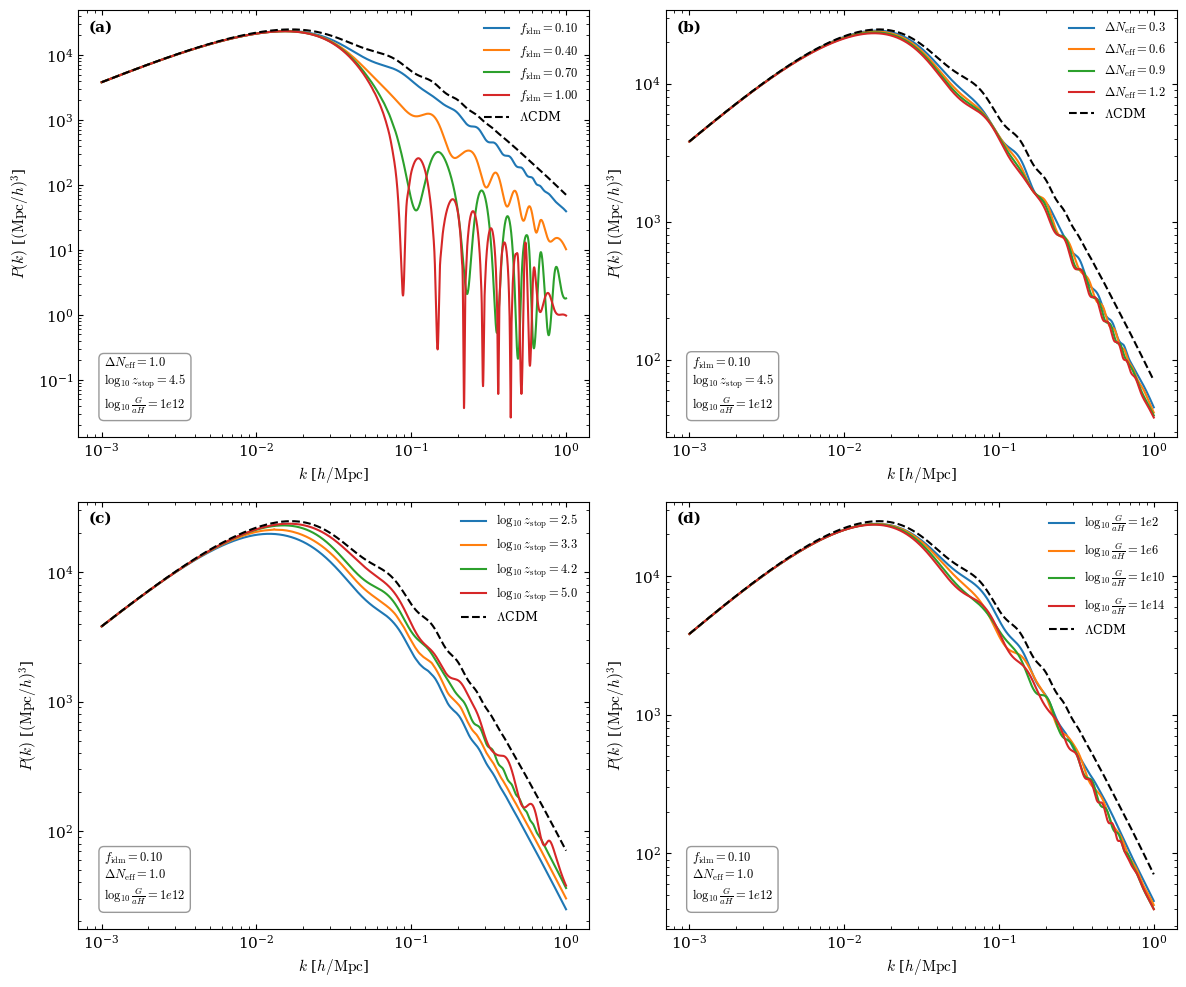

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration & Fixed Values ---
fiducial = {
    'f_idm': 0.1,
    'dNeff': 1.0,
    'logz': 4.5,
    'GaH': 12
}
fiducial_lcdm = {
    'f_idm': 0.0,
    'dNeff': 0.0,
    'logz': 2.0,
    'GaH': 0.0
}

plt.rcParams.update({
    'font.size': 11, 
    'font.family': 'serif',
    'mathtext.fontset': 'cm'
})

fig, ax = plt.subplots(2, 2, figsize=(12, 10)) 

def add_fixed_params_box(axis, fixed_str, loc='lower left'):
    box_props = dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8)
    if loc == 'upper right':
        x, y, ha, va = 0.95, 0.95, 'right', 'top'
    elif loc == 'upper left':
        x, y, ha, va = 0.05, 0.95, 'left', 'top'
    else:
        x, y, ha, va = 0.05, 0.05, 'left', 'bottom'
        
    axis.text(x, y, fixed_str, transform=axis.transAxes, 
              fontsize=9, verticalalignment=va, horizontalalignment=ha, bbox=box_props)

# ---------------------------------------------------------
# Plot 0,0: f_idm
# ---------------------------------------------------------
interaction_fraction = np.linspace(0.1, 1, 4) 
for f_idm in interaction_fraction:
    k_vals, p_k_nede, *_ = f_idm_model(f_idm, fiducial["dNeff"], fiducial["logz"], fiducial["GaH"])
    label_str = r'$f_{\mathrm{idm}} = ' + '{:.2f}$'.format(f_idm)
    ax[0, 0].plot(k_vals, p_k_nede, label=label_str)

lcdm = f_idm_model(0.0, fiducial_lcdm["dNeff"], fiducial_lcdm["logz"], fiducial_lcdm["GaH"])
ax[0, 0].plot(lcdm[0], lcdm[2], color='black', linestyle='--', label=r'$\Lambda$CDM')

fixed_txt = (
    rf"$\Delta N_{{\mathrm{{eff}}}} = {fiducial['dNeff']:.1f}$" + "\n" +
    rf"$\log_{{10}}z_{{\mathrm{{stop}}}} = {fiducial['logz']:.1f}$" + "\n" +
    rf"$\log_{{10}}\frac{{G}}{{aH}} = 1e{fiducial['GaH']:.0f}$"
)

add_fixed_params_box(ax[0, 0], fixed_txt, loc='lower left')
ax[0, 0].legend(fontsize=9, frameon=False, loc='upper right')
ax[0, 0].text(0.02, 0.95, "(a)", transform=ax[0, 0].transAxes, fontweight='bold')

# ---------------------------------------------------------
# Plot 0,1: Delta Neff
# ---------------------------------------------------------
delta_Neff_values = [0.3, 0.6, 0.9, 1.2]
for val in delta_Neff_values:
    k_vals, p_k_nede, *_ = delta_Neff_model(val, fiducial["f_idm"], fiducial["logz"], fiducial["GaH"])
    label_str = r'$\Delta N_{\mathrm{eff}} = ' + '{:.1f}$'.format(val)
    ax[0, 1].plot(k_vals, p_k_nede, label=label_str)

ax[0, 1].plot(lcdm[0], lcdm[2], color='black', linestyle='--', label=r'$\Lambda$CDM')

fixed_txt = (
    rf"$f_{{\mathrm{{idm}}}} = {fiducial['f_idm']:.2f}$" + "\n" +
    rf"$\log_{{10}}z_{{\mathrm{{stop}}}} = {fiducial['logz']:.1f}$" + "\n" +
    rf"$\log_{{10}}\frac{{G}}{{aH}} = 1e{fiducial['GaH']:.0f}$"
)
add_fixed_params_box(ax[0, 1], fixed_txt, loc='lower left')
ax[0, 1].legend(fontsize=9, frameon=False)
ax[0, 1].text(0.02, 0.95, "(b)", transform=ax[0, 1].transAxes, fontweight='bold')

# ---------------------------------------------------------
# Plot 1,0: log10z_stop
# ---------------------------------------------------------
log10z_stop_values = np.linspace(2.5, 5, 4)
for z_stop in log10z_stop_values:
    k_vals, p_k_nede, *_ = log10z_stop_model(z_stop, fiducial["f_idm"], fiducial["dNeff"], fiducial["GaH"])
    label_str = r'$\log_{10}z_{\mathrm{stop}} = ' + '{:.1f}$'.format(z_stop)
    ax[1, 0].plot(k_vals, p_k_nede, label=label_str)

ax[1, 0].plot(lcdm[0], lcdm[2], color='black', linestyle='--', label=r'$\Lambda$CDM')

fixed_txt = (
    rf"$f_{{\mathrm{{idm}}}} = {fiducial['f_idm']:.2f}$" + "\n" +
    rf"$\Delta N_{{\mathrm{{eff}}}} = {fiducial['dNeff']:.1f}$" + "\n" +
    rf"$\log_{{10}}\frac{{G}}{{aH}} = 1e{fiducial['GaH']:.0f}$"
)
add_fixed_params_box(ax[1, 0], fixed_txt, loc='lower left')
ax[1, 0].legend(fontsize=9, frameon=False)
ax[1, 0].text(0.02, 0.95, "(c)", transform=ax[1, 0].transAxes, fontweight='bold')

# ---------------------------------------------------------
# Plot 1,1: G/aH
# ---------------------------------------------------------
G_over_aH_values = np.linspace(2, 14, 4)
for gah in G_over_aH_values:
    k_vals, p_k_nede, *_ = G_over_aH_drmd_model(gah, fiducial["f_idm"], fiducial["dNeff"], fiducial["logz"])
    label_str = r'$\log_{10}\frac{G}{aH} = 1e{' + '{:.0f}'.format(gah) + '}$'
    ax[1, 1].plot(k_vals, p_k_nede, label=label_str)

ax[1, 1].plot(lcdm[0], lcdm[2], color='black', linestyle='--', label=r'$\Lambda$CDM')

fixed_txt = (
    rf"$f_{{\mathrm{{idm}}}} = {fiducial['f_idm']:.2f}$" + "\n" +
    rf"$\Delta N_{{\mathrm{{eff}}}} = {fiducial['dNeff']:.1f}$" + "\n" +
    rf"$\log_{{10}}\frac{{G}}{{aH}} = 1e{fiducial['GaH']:.0f}$"
)
add_fixed_params_box(ax[1, 1], fixed_txt, loc='lower left')
ax[1, 1].legend(fontsize=9, frameon=False)
ax[1, 1].text(0.02, 0.95, "(d)", transform=ax[1, 1].transAxes, fontweight='bold')

# --- Final Global Formatting ---
for a in ax.flat:
    a.set_xscale('log')
    a.set_yscale('log')
    a.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    a.set_ylabel(r'$P(k)$ [$(\mathrm{Mpc}/h)^3$]')
    a.tick_params(axis='both', which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
interaction_fraction = np.linspace(0, 0.2, 5)
delta_Neff_values = [0.0, 0.3, 0.6, 0.9, 1.2]
log10z_stop_values = np.linspace(2,5,5)
G_over_aH_drmd_values = np.logspace(2,14,5)

# f_idm_drmd
for f_idm in interaction_fraction:
    k_vals, _, _, ells, cls_NEDE_tt, cls_lcdm_tt = f_idm_model(f_idm)
    D_ell = ells * (ells + 1) * cls_NEDE_tt / (2 * np.pi)
    ax[0, 0].plot(ells, D_ell, label=f'f_idm_drmd={f_idm:.2f}', linestyle='-')

# LCDM reference
lcdm_vals = f_idm_model(0.0)
D_ell_lcdm = lcdm_vals[3] * (lcdm_vals[3] + 1) * lcdm_vals[5] / (2*np.pi)
ax[0, 0].plot(lcdm_vals[3], D_ell_lcdm, label='LCDM', linestyle='--')

ax[0, 0].set_xscale('linear')
ax[0, 0].set_yscale('linear')
ax[0, 0].set_xlabel(r'$\ell$')
ax[0, 0].set_ylabel(r'$l(l+1)D_\ell^{TT}/2pi$')
ax[0, 0].set_title('TT Spectrum for different $f_{idm,drmd}$')
ax[0, 0].legend()

box_props = dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
ax[0, 0].text(
    ax[0, 0].get_xlim()[0],  
    ax[0, 0].get_ylim()[0],  
    r'$\Delta N_{eff,drmd}=1.0$',  
    bbox=box_props,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='left'
)

# delta_Neff
for val in delta_Neff_values:
    _, _, _, ells, cls_NEDE_tt, _ = delta_Neff_model(val)
    D_ell = ells * (ells + 1) * cls_NEDE_tt / (2*np.pi)
    ax[0, 1].plot(ells, D_ell, label=f'ΔN_eff={val:.2f}', linestyle='-')

# LCDM reference
_, _, _, ells, cls_NEDE_tt, cls_lcdm_tt = delta_Neff_model(0.0)
D_ell_lcdm = ells * (ells + 1) * cls_lcdm_tt / (2*np.pi)
ax[0, 1].plot(ells, D_ell_lcdm, label='LCDM', linestyle='--')

ax[0, 1].set_xscale('linear')
ax[0, 1].set_yscale('linear')
ax[0, 1].set_xlabel(r'$\ell$')
ax[0, 1].set_ylabel(r'$l(l+1)D_\ell^{TT}/2pi$')
ax[0, 1].set_title('TT Spectrum for different ΔN_eff')
ax[0, 1].legend()

box_props = dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
ax[0, 1].text(
    ax[0, 0].get_xlim()[0],  
    ax[0, 0].get_ylim()[0],  
    r'$f_{idm,drmd}=0.1$',  
    bbox=box_props,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='left'
)

# log10z_stop
for val in log10z_stop_values:
    _, _, _, ells, cls_NEDE_tt, _ = log10z_stop_model(val)
    D_ell = ells * (ells + 1) * cls_NEDE_tt / (2*np.pi)
    ax[1, 0].plot(ells, D_ell, label=f'log10z_stop={val:.2f}', linestyle='-')

_, _, _, ells, _, cls_lcdm_tt = log10z_stop_model(2.0)
D_ell_lcdm = ells * (ells + 1) * cls_lcdm_tt / (2*np.pi)
ax[1, 0].plot(ells, D_ell_lcdm, label='LCDM', linestyle='--')

ax[1, 0].set_xscale('linear')
ax[1, 0].set_yscale('linear')
ax[1, 0].set_xlabel(r'$\ell$')
ax[1, 0].set_ylabel(r'l(l+1)$D_\ell^{TT}/2pi$')
ax[1, 0].set_title('TT Spectrum for different log10z_stop')
ax[1, 0].legend()

# G_over_aH_drmd
for val in G_over_aH_drmd_values:
    _, _, _, ells, cls_NEDE_tt, _ = G_over_aH_drmd_model(val)
    D_ell = ells * (ells + 1) * cls_NEDE_tt / (2*np.pi)
    ax[1, 1].plot(ells, D_ell, label=f'G/aH={val:.2e}', linestyle='-')

_, _, _, ells, _, cls_lcdm_tt = G_over_aH_drmd_model(0.0)
D_ell_lcdm = ells * (ells + 1) * cls_lcdm_tt / (2*np.pi)
ax[1, 1].plot(ells, D_ell_lcdm, label='LCDM', linestyle='--')

ax[1, 1].set_xscale('linear')
ax[1, 1].set_yscale('linear')
ax[1, 1].set_xlabel(r'$\ell$')
ax[1, 1].set_ylabel(r'$l(l+1)D_\ell^{TT}/2pi$')
ax[1, 1].set_title('TT Spectrum for different G/(aH)_drmd')
ax[1, 1].legend()

plt.tight_layout()
plt.show()


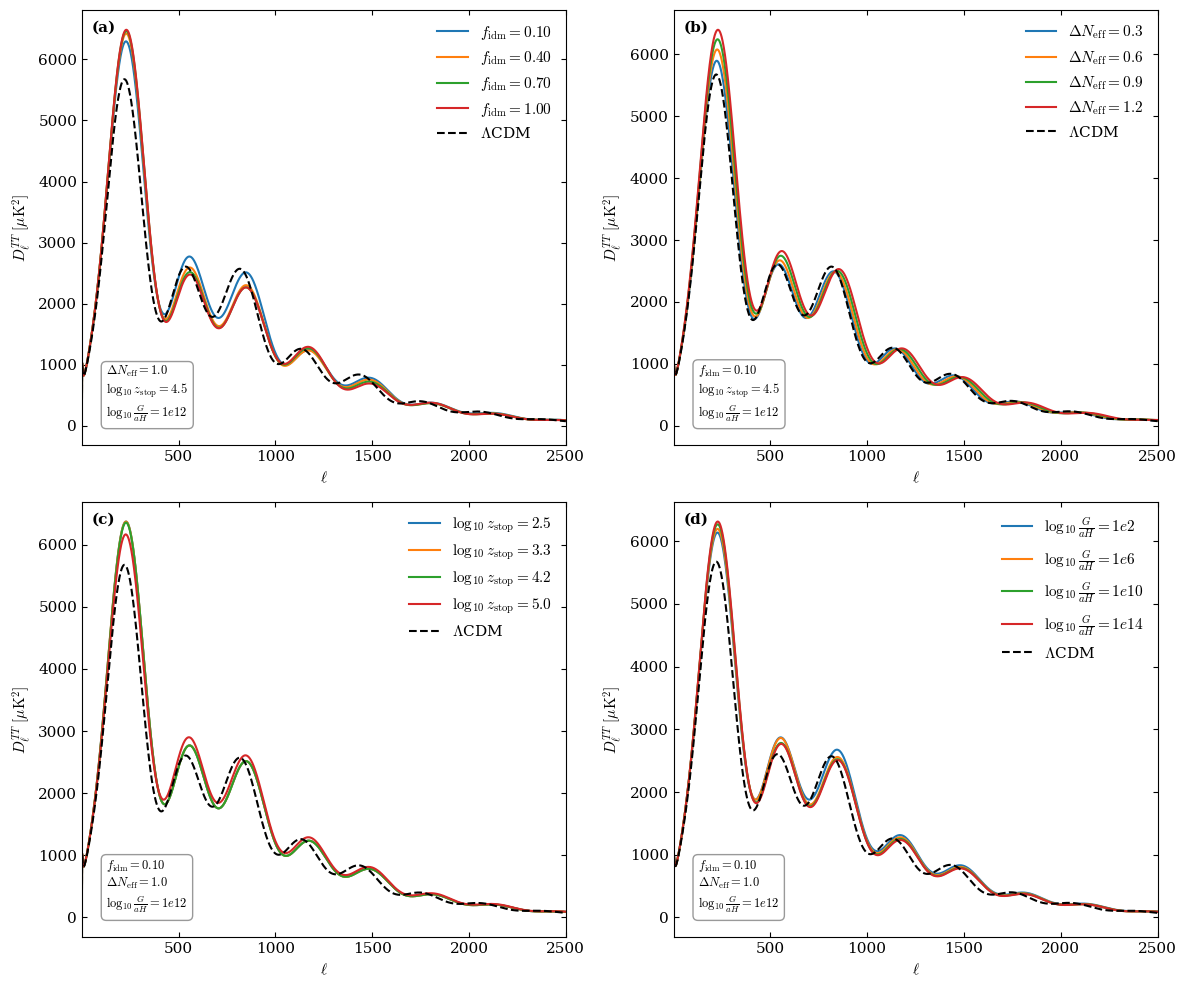

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
fiducial = {
    'f_idm': 0.1,
    'dNeff': 1.0,
    'logz': 4.5,
    'GaH': 12
}

plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'mathtext.fontset': 'cm'
})

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

def add_fixed_params_box(axis, text, loc='lower left'):
    box_props = dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8)
    if loc == 'upper right':
        x, y, ha, va = 0.95, 0.95, 'right', 'top'
    elif loc == 'upper left':
        x, y, ha, va = 0.05, 0.95, 'left', 'top'
    else:
        x, y, ha, va = 0.05, 0.05, 'left', 'bottom'

    axis.text(x, y, text, transform=axis.transAxes,
              fontsize=9, ha=ha, va=va, bbox=box_props)

# Helper (FIXED)
def compute_Dell(ells, cls):
    T_cmb = 2.7255  # Kelvin
    return ells * (ells + 1) * cls / (2 * np.pi) * (T_cmb * 1e6)**2

# ---------------------------------------------------------
# (a) f_idm
# ---------------------------------------------------------
interaction_fraction = np.linspace(0.1, 1, 4)

for f_idm in interaction_fraction:
    _, _, _, ells, cls_tt, _ = f_idm_model(
        f_idm, fiducial["dNeff"], fiducial["logz"], fiducial["GaH"]
    )
    ax[0, 0].plot(ells, compute_Dell(ells, cls_tt),
                  label=rf'$f_{{\mathrm{{idm}}}} = {f_idm:.2f}$')

# LCDM
_, _, _, ells, _, cls_lcdm = f_idm_model(0.0, 0, 2, 0)
ax[0, 0].plot(ells, compute_Dell(ells, cls_lcdm),
              'k--', label=r'$\Lambda$CDM')

fixed_txt = (
    rf"$\Delta N_{{\mathrm{{eff}}}} = {fiducial['dNeff']:.1f}$" + "\n" +
    rf"$\log_{{10}}z_{{\mathrm{{stop}}}} = {fiducial['logz']:.1f}$" + "\n" +
    rf"$\log_{{10}}\frac{{G}}{{aH}} = 1e{{{fiducial['GaH']:.0f}}}$"
)

add_fixed_params_box(ax[0, 0], fixed_txt, 'lower left')
ax[0, 0].legend(loc='upper right', frameon=False)
ax[0, 0].text(0.02, 0.95, "(a)", transform=ax[0, 0].transAxes, fontweight='bold')

# ---------------------------------------------------------
# (b) Delta Neff
# ---------------------------------------------------------
delta_vals = [0.3, 0.6, 0.9, 1.2]

for val in delta_vals:
    _, _, _, ells, cls_tt, _ = delta_Neff_model(
        val, fiducial["f_idm"], fiducial["logz"], fiducial["GaH"]
    )
    ax[0, 1].plot(ells, compute_Dell(ells, cls_tt),
                  label=rf'$\Delta N_{{\mathrm{{eff}}}} = {val:.1f}$')

ax[0, 1].plot(ells, compute_Dell(ells, cls_lcdm), 'k--', label=r'$\Lambda$CDM')

fixed_txt = (
    rf"$f_{{\mathrm{{idm}}}} = {fiducial['f_idm']:.2f}$" + "\n" +
    rf"$\log_{{10}}z_{{\mathrm{{stop}}}} = {fiducial['logz']:.1f}$" + "\n" +
    rf"$\log_{{10}}\frac{{G}}{{aH}} = 1e{{{fiducial['GaH']:.0f}}}$"
)

add_fixed_params_box(ax[0, 1], fixed_txt)
ax[0, 1].legend(frameon=False)
ax[0, 1].text(0.02, 0.95, "(b)", transform=ax[0, 1].transAxes, fontweight='bold')

# ---------------------------------------------------------
# (c) log10 z_stop
# ---------------------------------------------------------
z_vals = np.linspace(2.5, 5, 4)

for z in z_vals:
    _, _, _, ells, cls_tt, _ = log10z_stop_model(
        z, fiducial["f_idm"], fiducial["dNeff"], fiducial["GaH"]
    )
    ax[1, 0].plot(ells, compute_Dell(ells, cls_tt),
                  label=rf'$\log_{{10}}z_{{\mathrm{{stop}}}} = {z:.1f}$')

ax[1, 0].plot(ells, compute_Dell(ells, cls_lcdm), 'k--', label=r'$\Lambda$CDM')

fixed_txt = (
    rf"$f_{{\mathrm{{idm}}}} = {fiducial['f_idm']:.2f}$" + "\n" +
    rf"$\Delta N_{{\mathrm{{eff}}}} = {fiducial['dNeff']:.1f}$" + "\n" +
    rf"$\log_{{10}}\frac{{G}}{{aH}} = 1e{{{fiducial['GaH']:.0f}}}$"
)

add_fixed_params_box(ax[1, 0], fixed_txt)
ax[1, 0].legend(frameon=False)
ax[1, 0].text(0.02, 0.95, "(c)", transform=ax[1, 0].transAxes, fontweight='bold')

# ---------------------------------------------------------
# (d) G/aH
# ---------------------------------------------------------
G_vals = np.linspace(2, 14, 4)

for g in G_vals:
    _, _, _, ells, cls_tt, _ = G_over_aH_drmd_model(
        g, fiducial["f_idm"], fiducial["dNeff"], fiducial["logz"]
    )
    ax[1, 1].plot(ells, compute_Dell(ells, cls_tt),
                  label=rf'$\log_{{10}}\frac{{G}}{{aH}} = 1e{{{g:.0f}}}$')

ax[1, 1].plot(ells, compute_Dell(ells, cls_lcdm), 'k--', label=r'$\Lambda$CDM')

fixed_txt = (
    rf"$f_{{\mathrm{{idm}}}} = {fiducial['f_idm']:.2f}$" + "\n" +
    rf"$\Delta N_{{\mathrm{{eff}}}} = {fiducial['dNeff']:.1f}$" + "\n" +
    rf"$\log_{{10}}\frac{{G}}{{aH}} = 1e{{{fiducial['GaH']:.0f}}}$"
)

add_fixed_params_box(ax[1, 1], fixed_txt)
ax[1, 1].legend(frameon=False)
ax[1, 1].text(0.02, 0.95, "(d)", transform=ax[1, 1].transAxes, fontweight='bold')

# ---------------------------------------------------------
# Global formatting
# ---------------------------------------------------------
for a in ax.flat:
    a.set_xlabel(r'$\ell$')
    a.set_ylabel(r'$D_\ell^{TT}\;[\mu\mathrm{K}^2]$')
    a.set_xlim(2, 2500)
    a.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()